## Interactive Bayesian Optimization (w/UCB Acquisition) for Function 6

Note: This code recommends the next point based on historical data.

Submit the recommended point to the Capstone project portal, obtain the output, then update `input.npy` and `output.npy`.

You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is **negative** by design.

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
# from sklearn.gaussian_process.kernels import ConstantKernel
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Input
from scipy.stats import norm
import random
import os

In [2]:
# Load and check initial data

# Initial INPUT file path
X_init = np.load(r"initial_data\function_6\initial_inputs.npy")
# Initial OUTPUT file path
y_init = np.load(r"initial_data\function_6\initial_outputs.npy")


# INPUT file storing historical inputs 5D array (n, dim)
input_file = r"initial_data\function_6\inputs.npy"
# OUTPUT file storing historical outputs 1D array (n, )
output_file = r"initial_data\function_6\outputs.npy"

if os.path.exists(input_file) and os.path.exists(output_file):
    print(f"Historical INPUT contains {len(np.load(input_file))} points:\n", np.load(input_file))
    print(f"Historical OUTPUT contains {len(np.load(output_file))} points:\n", np.load(output_file))
else:
    print(f"Initial INPUT contains {len(X_init)} points:\n", X_init)
    print(f"Initial INPUT contains {len(y_init)} points:\n", y_init)

Historical INPUT contains 26 points:
 [[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191 

In [3]:
# 1. Configuration

# INPUT dimensionality
dim = 5
len_init = len(X_init)

# Bounds for each dimension
bounds = np.array([[0, 0.999999]] * dim)

# Number of candidate points
n_candidates = 1000

rbf_lengthscale = 0.1
noise_assumption = 1e-10
beta = 1.96
random.seed(23)
np.random.seed(23)

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Conduct a grid research if the optimal output has not improved over several queries and exploration is insufficient.
- Alternate between UCB and EI if exploration seems insufficient.

In [4]:
search_model = 'nn'    # 'grid' or 'gp' or 'nn'

grid_density = 40

acquisition_type = 'ucb'    # 'ucb' or 'ei', for grid search

In [5]:
# 2. Helper functions

# Load historical data from input.npy and output.npy
def load_data():
    if os.path.exists(input_file) and os.path.exists(output_file):
        print("Load historical data")
        X = np.load(input_file)
        y = np.load(output_file)
        # ensure dimensions match
        if X.shape[0] != y.shape[0]:
            raise ValueError(f"input.npy and output.npy mismatch: {X.shape[0]} vs {y.shape[0]}")
        return X, y
    else:
        print("Load initial data")
        X = X_init
        y = y_init
        return X, y

# Save historical data to input.npy and output.npy
def save_data(X, y):
    np.save(input_file, X)
    np.save(output_file, y)

# Upper Confidence Bound (UCB) acquisition function
def ucb_acquisition(x_cand, model, beta):
    post_mean, post_std = model.predict(x_cand, return_std = True)
    # avoid zero standard deviation
    post_std = np.maximum(post_std, 1e-9)
    return post_mean + beta * post_std

# Recommend the next point to evaluate
def suggest_next_point(X, y, trust_region, beta):
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1.0))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0, normalize_y = True)
    model.fit(X, y)
    
    # Generate candidate points
    #candidates = np.random.uniform(bounds[:, 0], bounds[:, 1], size = (n_candidates, dim))
    candidates = samples_in_trust_region(trust_region, n_candidates)
    
    # Exclude points that have already been evaluated
    from sklearn.neighbors import NearestNeighbors
    neighbors = NearestNeighbors(n_neighbors = 1, algorithm = 'auto').fit(X)
    distances, _ = neighbors.kneighbors(candidates)
    mask = distances.flatten() > 1e-6
    candidates = candidates[mask]

    print("Use Upper Confidence Bound (UCB) acquisition function within Trust Region.")
    ucb_values = ucb_acquisition(candidates, model, beta)
    next_idx = np.argmax(ucb_values)
    x_next = candidates[next_idx]
    mean, std = model.predict(x_next.reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean.item():.6f}, std = {std.item():.6f}, UCB = {mean.item() + beta * std.item():.6f}")
    return x_next, ucb_values[next_idx]

# Plot optimization progress
def plot_progress(X, y, beta):
    #best_so_far = np.maximum.accumulate(y)
    plt.figure(figsize = (8, 4))
    #plt.plot(range(1, len(best_so_far) + 1), best_so_far, 'b-o', markersize = 4)
    plt.plot(range(1, len(y) + 1), y, 'b-o', markersize = 4)
    plt.xlabel('Number of evaluations')
    #plt.ylabel('Best Output found so far')
    plt.ylabel('Every Output found so far')
    plt.title('Optimization Progress (UCB, β={})'.format(beta, beta))
    plt.grid(True)
    plt.show()

# Convert an integer into its ordinal string
def ordinal(n):
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

- Define a function to check whether the optimal output has been unimproved over several queries.
- Define a grid research function to find the point that maximizes the acquisition function.
- Increase `length_scale` of the kernel function to try to improve the fitness of model.

In [6]:
'''
# Check if the optimal output has been unimproved
def check_unimproved(y, window = 3, tolerance = 1e-6):
    y_accumulate = np.maximum.accumulate(y)
    recent_best = y_accumulate[-window: ]
    return (np.max(recent_best) - np.min(recent_best)) < tolerance
'''

# Define a grid search function
def grid_search_acquisition(X, y, bounds, grid_density, acquisition_type, xi = 0.01):
    # Generate grid
    axes = [np.linspace(bounds[d, 0], bounds[d, 1], grid_density) for d in range(dim)]
    mesh = np.array(np.meshgrid(*axes)).T.reshape(-1, dim)

    # Retrain the GP model
    kernel = RBF(length_scale = rbf_lengthscale, length_scale_bounds = (0.01, 10.0)) \
             + WhiteKernel(noise_level = 1e-5, noise_level_bounds = (1e-6, 1e-1))
    model = GaussianProcessRegressor(kernel = kernel, alpha = 0.0)
    model.fit(X, y)

    # Compute acquisition value
    if acquisition_type == 'ucb':
        print("Use Upper Confidence Bound (UCB) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        # avoid zero standard deviation
        mesh_std = np.maximum(mesh_std, 1e-9)
        acquisition_value = mesh_mean + beta * mesh_std
    elif acquisition_type == 'ei':
        print("Use Expected Improvement (EI) acquisition function.")
        mesh_mean, mesh_std = model.predict(mesh, return_std = True)
        mesh_std = np.maximum(mesh_std, 1e-9)
        y_max = np.max(y)
        z = (mesh_mean - y_max - xi) / mesh_std
        acquisition_value = (mesh_mean - y_max - xi) * norm.cdf(z) + mesh_std * norm.pdf(z)
    else:
        raise ValueError("acquisition_type must be 'ucb' or 'ei'")

    next_idx = np.argmax(acquisition_value)
    mean, std = model.predict(mesh[next_idx].reshape(1,-1), return_std = True)
    print(f"Predicted mean = {mean.item():.6f}, std = {std.item():.6f}, UCB = {mean.item() + beta * std.item():.6f}")
    return mesh[next_idx], acquisition_value[next_idx]

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement the Trust Region approach. <br>Based on the current optimal output point, define a hypercube Trust Region. If the optimal outputs improve continuously, expand the radius; if no improvement, reduce the radius.

In [7]:
trust_region_file = r"initial_data\function_6\trust_region.npy"

def load_trust_region(X, y, filename = trust_region_file):
    if os.path.exists(filename):
        region = np.load(filename, allow_pickle = True).item()
        best_so_far = X[np.argmax(y)]
        if not np.array_equal(region['center'], best_so_far):
            region['center'] = best_so_far.copy()
        return region
    else:
        center = X[np.argmax(y)]
        print("Create initial Trust Region.")
        return {
            'center': center.copy(),
            'radius': 0.1,
            'bounds': bounds,
            'improvement_counter': 0,
            'unimprovement_counter': 0
        }

'''
def init_trust_region(center, radius = 0.1, bounds = bounds):
    return {
        'center': center.copy(),
        'radius': radius,
        'bounds': bounds,
        'improvement_counter': 0,
        'unimprovement_counter': 0
    }
'''

def save_trust_region(region, filename = trust_region_file):
    region_to_save = {
        'center': region['center'],
        'radius': region['radius'],
        'bounds': region['bounds'],
        'improvement_counter': region['improvement_counter'],
        'unimprovement_counter': region['unimprovement_counter']
    }
    np.save(filename, region_to_save, allow_pickle=True)
    print("Trust Region file is updated.")


def update_trust_region(region, new_center, improved = False):
    region['center'] = new_center.copy()
    if improved:
        region['improvement_counter'] += 1
        region['unimprovement_counter'] = 0
        if region['improvement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.2, 0.5)
            print(f"Trust Region shrunk to radius {region['radius']:.4f}")
            region['improvement_counter'] = 0
    else:
        region['unimprovement_counter'] += 1
        region['improvement_counter'] = 0
        if region['unimprovement_counter'] >= 2:
            region['radius'] = min(region['radius'] * 1.5, 0.5)
            print(f"Trust Region expanded to radius {region['radius']:.4f}")
            region['unimprovement_counter'] = 0
    save_trust_region(region)

def samples_in_trust_region(region, n_points):
    n_local = int(n_points * 0.2)
    n_global = n_points - n_local
    lower = np.maximum(region['center'] - region['radius'], region['bounds'][:, 0])
    upper = np.minimum(region['center'] + region['radius'], region['bounds'][:, 1])
    lower = np.clip(lower, region['bounds'][:, 0], region['bounds'][:, 1])
    upper = np.clip(upper, region['bounds'][:, 0], region['bounds'][:, 1])
    local_samples = np.random.uniform(lower, upper, size = (n_local, dim))
    global_samples = np.random.uniform(region['bounds'][:, 0], region['bounds'][:,1], size = (n_global, dim))
    return np.vstack([local_samples, global_samples])

**Apr. 28<sup>th</sup>** (before 4<sup>th</sup> submission)

- Define functions to implement Neural Network. <br>

In [8]:
tf.random.set_seed(23)

def build_nn_model():
    model = tf.keras.Sequential([
        Input(shape = (dim,)),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(32, activation = 'relu'),
        tf.keras.layers.Dense(1)
    ])
    return model

def suggest_by_nn(X, y, trust_region, epochs = 200, n_restarts = 5, n_steps = 50, learning_rate = 0.1):
    print('Use neural network for exploration.')
    # standardize output
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).flatten()

    # train model
    model = build_nn_model()
    model.compile(optimizer = tf.keras.optimizers.SGD(learning_rate = learning_rate),
                  loss = tf.keras.losses.MeanSquaredError())
    model.fit(X, y_scaled, epochs = epochs, verbose = 0)

    mean_y = y_scaler.mean_[0]
    scale_y = y_scaler.scale_[0]
    
    def gradient_ascent(x_start):
        x = tf.Variable(x_start.reshape(1, -1), dtype = tf.float32)
        for _ in range(n_steps):
            with tf.GradientTape() as tape:
                mean_scaled = model(x, training = False)[0, 0]
                mean = mean_scaled * scale_y + mean_y
                ucb = mean + beta * 0.1
            grads = tape.gradient(ucb, x)
            x.assign_add(0.01 * grads)
            x.assign(tf.clip_by_value(x, trust_region['bounds'][:, 0], trust_region['bounds'][:, 1]))
        return x.numpy()[0]

    x_next = None
    best_acquisition_value = -np.inf
    for _ in range(n_restarts):
        lower = np.maximum(trust_region['center'] - trust_region['radius'], trust_region['bounds'][:, 0])
        upper = np.minimum(trust_region['center'] + trust_region['radius'], trust_region['bounds'][:, 1])
        if np.any(upper <= lower):
            x_start = np.random.uniform(trust_region['bounds'][:, 0], trust_region['bounds'][:, 1])
        else:
            x_start = np.random.uniform(lower, upper)
        x_opt = gradient_ascent(x_start)

        # calculate UCB
        mean_scaled = model.predict(x_opt.reshape(1, -1), verbose = 0)[0, 0]
        mean = mean_scaled * scale_y + mean_y
        acquisition_value = mean + beta * 0.1
        if acquisition_value > best_acquisition_value:
            best_acquisition_value = acquisition_value
            x_next = x_opt
    print(f"Predicted mean = {mean:.6f}, constant std = 0.1, UCB = {mean + beta * 0.1}")
    return x_next, best_acquisition_value

Load historical data
Loaded 26 points. And the historical OUTPUT:
 [-0.71426495 -1.20995524 -1.67219994 -1.53605771 -0.82923655 -1.24704893
 -1.23378638 -1.69434344 -2.57116963 -1.30911635 -1.14478485 -1.91267714
 -1.62283895 -1.35668211 -2.0184254  -1.70255784 -1.29424696 -0.93575656
 -2.15576776 -1.74688209 -1.38790298 -2.45160965 -1.46081474 -0.82567005
 -0.64339747 -0.62653431]
Current best output: -0.626534


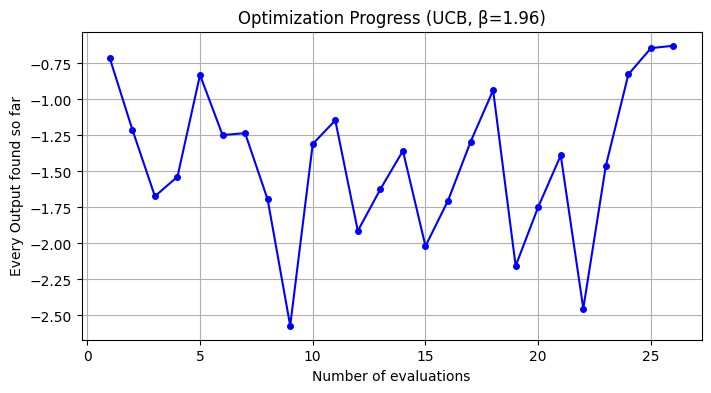

In [9]:
# 3. Load historical data and view current status
X, y = load_data()

print(f"Loaded {len(X)} points. And the historical OUTPUT:\n", y)

if len(y) > 0:
    previous_best = np.max(y)
    print(f"Current best output: {np.max(y):.6f}")
    plot_progress(X, y, beta)
else:
    print("Please load initial data")

**Apr. 11<sup>th</sup>** (before 2<sup>nd</sup> submission)

Check whether the optimal output has been unimproved over several queries. If yes, execute the grid research function.

In [10]:
# 4. Recommend the next point to submit

trust_region = load_trust_region(X, y)
print(f"Trust region center: {trust_region['center']}, radius: {trust_region['radius']:.4f}")

if search_model == 'grid':
    print("Detect output has been unimproved over several queries. Use grid search for exploration.")
    x_next, best_acquisition_value = grid_search_acquisition(X, y, bounds, grid_density, acquisition_type)
    print(f"Grid search selected point with acquisition value: {best_acquisition_value:.6f}")
elif search_model == 'gp':
    x_next, best_acquisition_value = suggest_next_point(X, y, trust_region, beta)
    print(f"GP selected point with acquisition value: {best_acquisition_value:.6f}")
elif search_model == 'nn':
    x_next, best_acquisition_value = suggest_by_nn(X, y, trust_region)
    print(f"Neural network selected point with acquisition value: {best_acquisition_value:.6f}")
else:
    raise ValueError("search_model must be 'grid', 'gp' or 'nn'")

submit_next = len(X) - len_init + 1
print(f"The {ordinal(submit_next)} recommended input point:")
print(np.round(x_next, 6))
print("-".join(map(str, np.round(x_next, 6))))

Trust region center: [0.40628532 0.04289719 0.5226838  0.71785939 0.00871553], radius: 0.1200
Use neural network for exploration.
Predicted mean = -0.699030, constant std = 0.1, UCB = -0.5030296167866306
Neural network selected point with acquisition value: -0.461122
The 7th recommended input point:
[0.451255 0.012999 0.575892 0.828945 0.      ]
0.451255-0.012999-0.575892-0.828945-0.0


In [ ]:
# 5. After obtaining the output from Capstone project portal, update the historical data

# Please manually enter the output value returned by Capstone project portal
y_new = float(input("Enter the output value returned by Capstone project portal: "))

# Append the new point to history
X = np.vstack([X, x_next])
y = np.append(y, y_new)

# Save updated data
save_data(X, y)
print("Historical data updated.")
print(f"There are {len(X)} points, and current best output: {np.max(y):.6f}")

plot_progress(X, y, beta)

# Update Trust Region
if np.max(y) > previous_best:
    improved = True
    print("Trust Region updated.")
else:
    improved = False
    print("Trust Region is not updated.")
best_X = X[np.argmax(y)]
update_trust_region(trust_region, best_X, improved)